# Exploratory Data Analysis — Superstore

This notebook answers the assignment questions using `superstore.csv` (place the CSV in the same folder as this notebook).

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4)
%matplotlib inline


In [2]:
# Load data (UTF-8: column names may include non-ASCII)
DATA_PATH = "superstore.csv"
raw = pd.read_csv(DATA_PATH, encoding="utf-8")
raw.head()


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,Order.Priority,Product.ID,Product.Name,Profit,Quantity,Region,Row.ID,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,High,OFF-PA-10002005,Xerox 225,9.3312,3,West,36624,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,Medium,OFF-PA-10002893,"Wirebound Service Call Books, 5 1/2"" x 4""",9.2928,2,West,37033,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,Medium,OFF-PA-10000659,"Adams Phone Message Book, Professional, 400 Me...",9.8418,3,West,31468,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,Medium,OFF-PA-10001144,Xerox 1913,53.2608,2,West,31469,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,High,OFF-PA-10002105,Xerox 223,3.1104,1,West,32440,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


## Q1: Data Cleaning

### Q1 i — Count and handle missing values


In [3]:
missing = raw.isnull().sum()
missing_pct = (missing / len(raw) * 100).round(3)
miss_df = pd.DataFrame({"missing_count": missing, "pct": missing_pct})
miss_df[miss_df["missing_count"] > 0]


,missing_count,pct
Shipping.Cost,5,0.010
State,3,0.006


In [4]:
# Fill numeric Shipping.Cost with median; State with mode (or 'Unknown' if needed)
df = raw.copy()
df["Shipping.Cost"] = df["Shipping.Cost"].fillna(df["Shipping.Cost"].median())
df["State"] = df["State"].fillna(df["State"].mode(dropna=True).iloc[0] if df["State"].mode(dropna=True).shape[0] else "Unknown")
print("Remaining NA:", df.isnull().sum().sum())


Remaining NA: 0


### Q1 ii — Duplicate values


In [5]:
dup_rows = df.duplicated().sum()
print("Fully duplicate rows:", dup_rows)
# Optional: drop duplicate rows for analysis (keeps first occurrence)
df = df.drop_duplicates(keep="first").reset_index(drop=True)
print("Shape after dropping duplicate rows:", df.shape)


Fully duplicate rows: 0
Shape after dropping duplicate rows: (51290, 27)


### Q1 iii — Delete unknown columns if present

Per the data dictionary, `ji_lu_shu` / `记录数` is an unknown record-count column and is removed.


In [6]:
unknown_cols = [c for c in df.columns if c in ("记录数", "ji_lu_shu")]
print("Dropping:", unknown_cols)
df = df.drop(columns=unknown_cols, errors="ignore")
df.columns.tolist()


Dropping: ['记录数']


['Category',
 'City',
 'Country',
 'Customer.ID',
 'Customer.Name',
 'Discount',
 'Market',
 'Order.Date',
 'Order.ID',
 'Order.Priority',
 'Product.ID',
 'Product.Name',
 'Profit',
 'Quantity',
 'Region',
 'Row.ID',
 'Sales',
 'Segment',
 'Ship.Date',
 'Ship.Mode',
 'Shipping.Cost',
 'State',
 'Sub.Category',
 'Year',
 'Market2',
 'weeknum']

### Q1 iv — Shape, size, and dtypes


In [7]:
print("Shape (rows, cols):", df.shape)
print("Size (cells):", df.size)
print(df.dtypes)


Shape (rows, cols): (51290, 26)
Size (cells): 1333540
Category           object
City               object
Country            object
Customer.ID        object
Customer.Name      object
Discount          float64
Market             object
Order.Date         object
Order.ID           object
Order.Priority     object
Product.ID         object
Product.Name       object
Profit            float64
Quantity            int64
Region             object
Row.ID              int64
Sales               int64
Segment            object
Ship.Date          object
Ship.Mode          object
Shipping.Cost     float64
State              object
Sub.Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object


**Q1 interpretation (short):** Missing values were limited (`Shipping.Cost`, `State`); we imputed to avoid dropping rows unnecessarily. Duplicate rows were removed. The unknown `记录数` column was dropped. The working frame retains order-line level granularity.


## Q2: Univariate analysis — numerical features

We analyze: `Discount`, `Profit`, `Quantity`, `Row.ID`, `Sales`, `Shipping.Cost`, `Year`, `weeknum` (after cleaning).


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols


['Discount',
 'Profit',
 'Quantity',
 'Row.ID',
 'Sales',
 'Shipping.Cost',
 'Year',
 'weeknum']

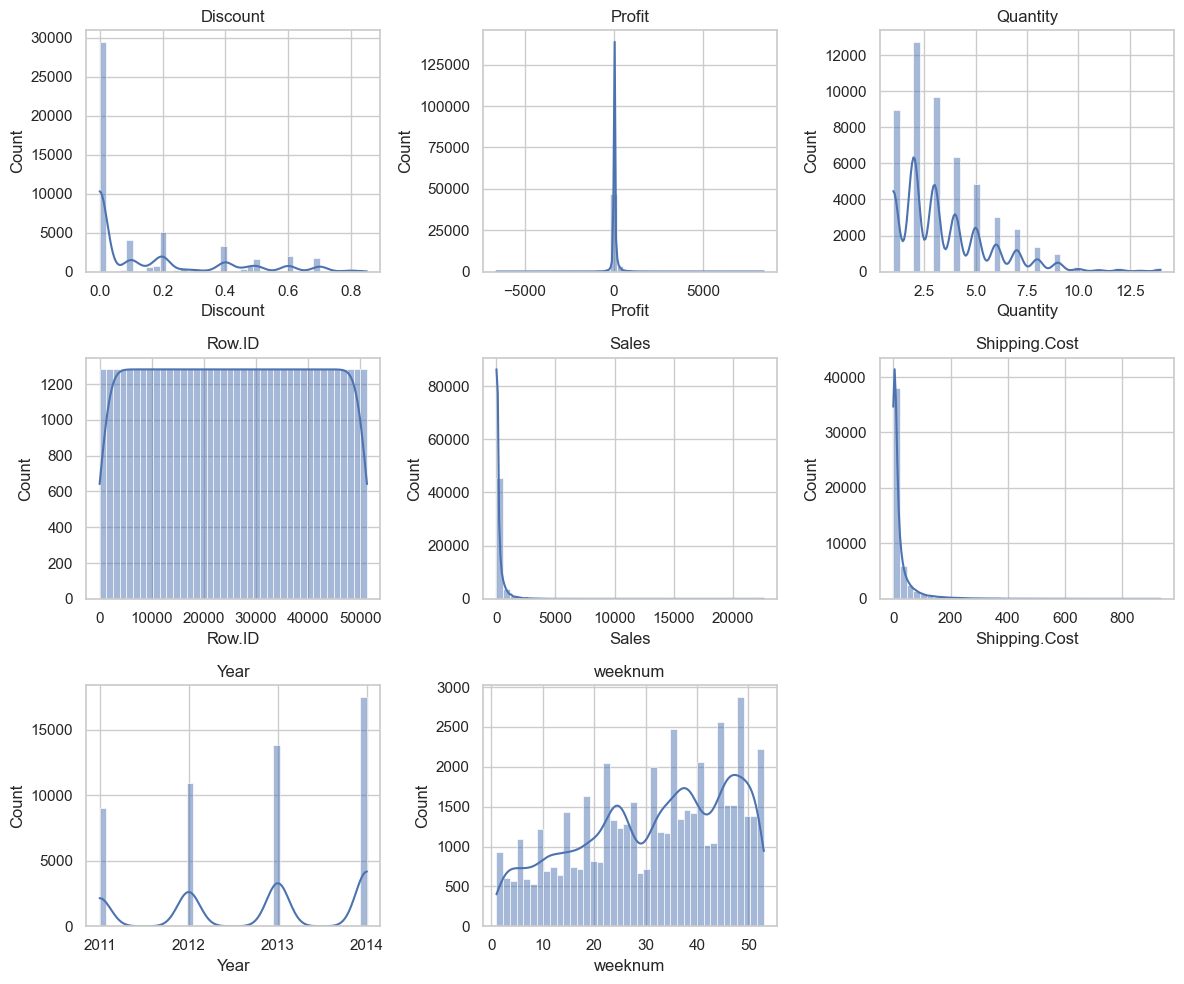

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.ravel()
for i, c in enumerate(num_cols):
    sns.histplot(df[c], kde=True, ax=axes[i], bins=40)
    axes[i].set_title(c)
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()


In [10]:
skew_tbl = pd.DataFrame({
    "skewness": df[num_cols].apply(lambda s: stats.skew(s.dropna())),
    "kurtosis": df[num_cols].apply(lambda s: stats.kurtosis(s.dropna())),
})
skew_tbl.round(3)


,skewness,kurtosis
Discount,1.388,0.716
Profit,4.157,291.383
Quantity,1.360,2.276
Row.ID,0.000,-1.200
Sales,8.138,176.706
Shipping.Cost,5.863,50.016
Year,-0.345,-1.222
weeknum,-0.342,-0.982


In [11]:
# IQR-based outlier counts (per feature, beyond 1.5*IQR)
def iqr_outlier_pct(s):
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return float(((s < lo) | (s > hi)).mean() * 100)

outlier_pct = pd.Series({c: iqr_outlier_pct(df[c]) for c in num_cols}, name="pct_outliers_IQR")
outlier_pct.round(2)


Discount          8.13
Profit           19.02
Quantity          1.71
Row.ID            0.00
Sales            11.03
Shipping.Cost    11.52
Year              0.00
weeknum           0.00
Name: pct_outliers_IQR, dtype: float64

### Q2 i — Which features seem useless?

**Answer:** `Row.ID` is a surrogate key with no business meaning for modeling or insight (high cardinality, arbitrary numbering). `Year` and `weeknum` are useful for time patterns but weak alone for cross-sectional profit drivers. `记录数` was already removed in Q1.


### Q2 ii — Uniform or normal?

**Answer:** None of the business metrics look like clean normal distributions on raw scales. `Row.ID` is roughly flat/uniform by construction (row index–like). `Year` is discrete with limited years (2011–2014), so it is closer to a discrete uniform than a bell curve. Most monetary/count features are heavy-tailed, not Gaussian.


### Q2 iii — Right-skewed / left-skewed?

**Answer:** `Sales`, `Profit`, `Shipping.Cost`, `Discount`, and `Quantity` are **right-skewed** (long right tails): a few large orders and high discounts pull the tail. That implies means are pulled above medians and averages overstate “typical” rows unless you transform or use robust stats. `Year` / `weeknum` show mild left skew / discrete structure rather than strong business skew.


### Q2 iv — Outliers and impact

**Answer:** `Sales` and `Profit` show many extreme values (heavy tails, high IQR-outlier rates). That inflates variance, hurts normality assumptions for some tests, and can dominate aggregates—use medians, robust scales, or winsorization for modeling; investigate large orders as business cases (bulk, returns, data errors).


## Q3: Univariate analysis — categorical features


In [12]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols


['Category',
 'City',
 'Country',
 'Customer.ID',
 'Customer.Name',
 'Market',
 'Order.Date',
 'Order.ID',
 'Order.Priority',
 'Product.ID',
 'Product.Name',
 'Region',
 'Segment',
 'Ship.Date',
 'Ship.Mode',
 'State',
 'Sub.Category',
 'Market2']

In [13]:
for c in cat_cols:
    print(c, "nunique =", df[c].nunique())


Category nunique = 3
City nunique = 3636
Country nunique = 147
Customer.ID nunique = 4873
Customer.Name nunique = 795
Market nunique = 7
Order.Date nunique = 1
Order.ID nunique = 25035
Order.Priority nunique = 4
Product.ID nunique = 10292
Product.Name nunique = 3788
Region nunique = 13
Segment nunique = 3
Ship.Date nunique = 1
Ship.Mode nunique = 4
State nunique = 1094
Sub.Category nunique = 17
Market2 nunique = 6


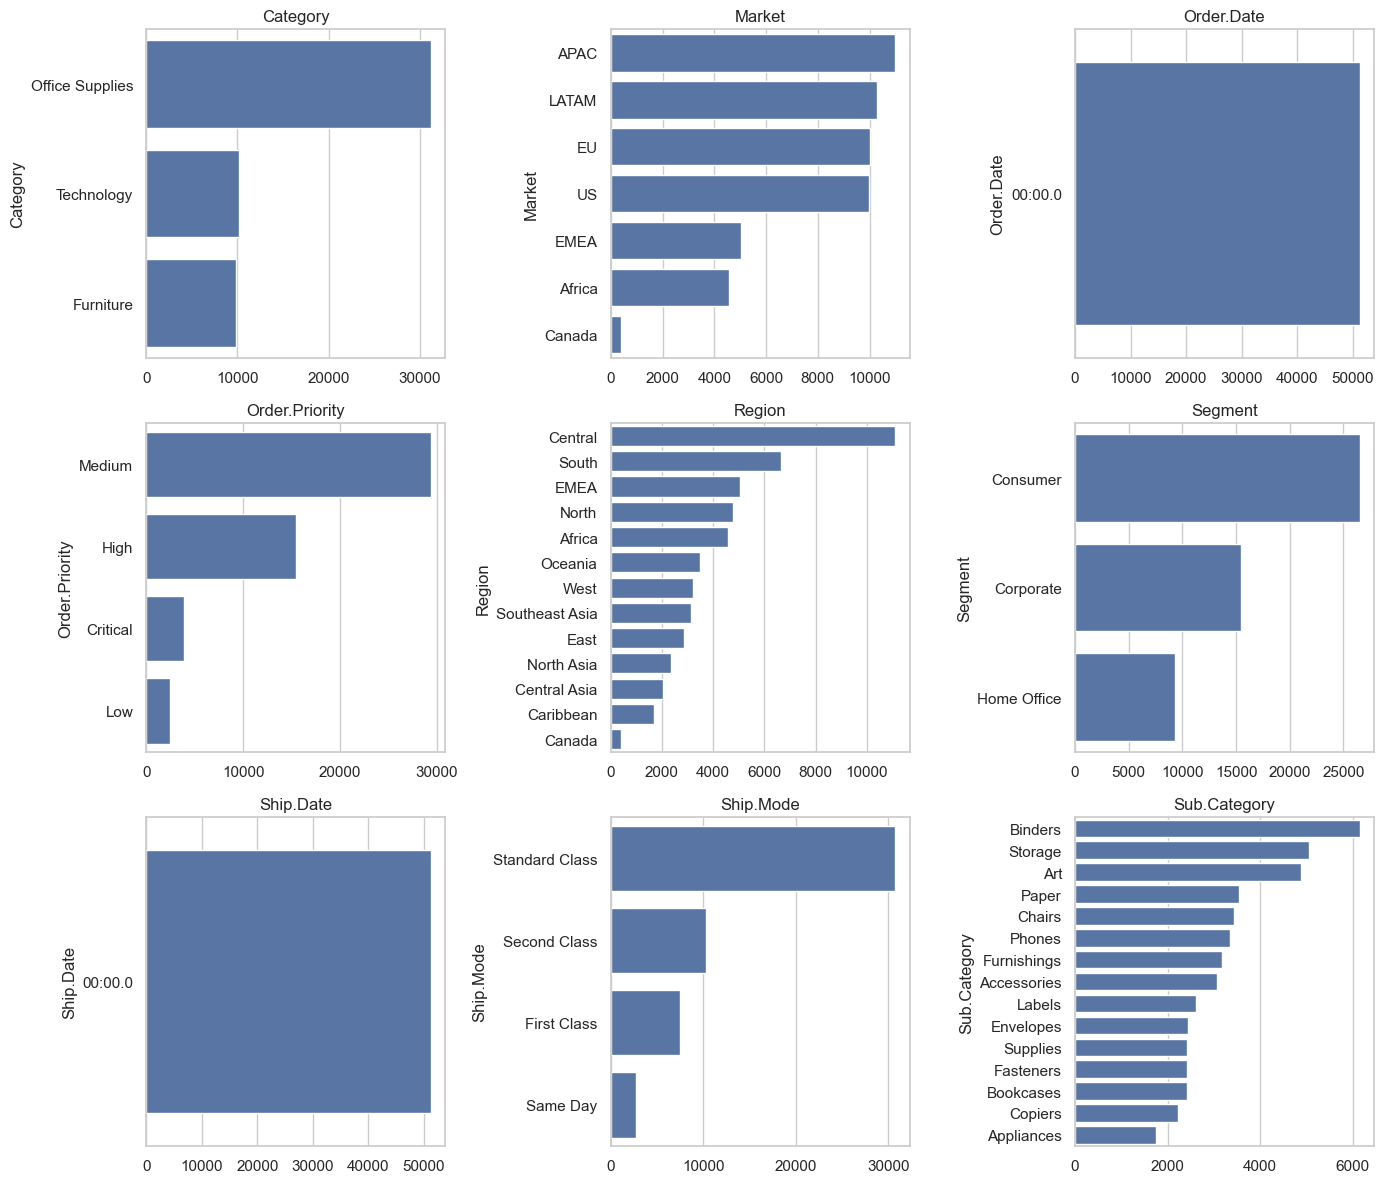

In [14]:
# Frequency plots for lower-cardinality columns
low_card = [c for c in cat_cols if df[c].nunique() <= 20]
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.ravel()
for i, c in enumerate(low_card[:9]):
    vc = df[c].value_counts().head(15)
    sns.barplot(x=vc.values, y=vc.index, ax=axes[i])
    axes[i].set_title(c)
plt.tight_layout()
plt.show()


### Q3 i — Inaccurate / not useful as direct “insights”

**Answer:** `Order.Date` and `Ship.Date` in this file are not valid calendar dates (they read as `00:00.0`), so they are **not reliable for time analysis** without repair. `Product.ID` / `Product.Name` / `Customer.ID` are ultra-high-cardinality labels—not useful as raw categorical buckets. `Market2` partially duplicates `Market`/`Region` semantics—redundant without clear definition.


### Q3 ii — Issue with `Customer.Name` as categorical for modeling

**Answer:** Almost every name is unique (or very sparse), so one-hot or label encoding explodes dimensionality, causes overfitting, and does not generalize to new customers—better to aggregate to customer-level features (RFM, lifetime value) or drop for many models.


### Q3 iii — Category balance

**Answer:** The distribution is **skewed**: Office Supplies account for roughly **61%** of rows, versus ~20% Technology and ~19% Furniture—so any overall metric is dominated by Office Supplies unless stratified.


In [15]:
df["Category"].value_counts(normalize=True).mul(100).round(2)


Category
Office Supplies    60.97
Technology         19.77
Furniture          19.26
Name: proportion, dtype: float64

### Q3 iv — Country dominance and geographic bias

**Answer:** **Yes — the United States dominates** (about **9,994** rows vs much smaller counts elsewhere), so global summaries mainly reflect the US market unless weighted or split by country.


In [16]:
df["Country"].value_counts().head(10)


Country
United States     9994
Australia         2837
France            2827
Mexico            2644
Germany           2065
China             1880
United Kingdom    1633
Brazil            1599
India             1555
Indonesia         1390
Name: count, dtype: int64

### Q3 v — City concentration

**Answer:** Cities are **spread out** (thousands of distinct cities); the top few cities only account for a small share of all rows, so geography is diffuse rather than a handful of megacities driving everything.


In [17]:
city_share_top10 = df["City"].value_counts().head(10).sum() / len(df)
print("Unique cities:", df["City"].nunique())
print("Share of orders in top 10 cities:", round(city_share_top10 * 100, 2), "%")


Unique cities: 3636
Share of orders in top 10 cities: 9.92 %


## Q4: Bivariate analysis — numerical vs numerical


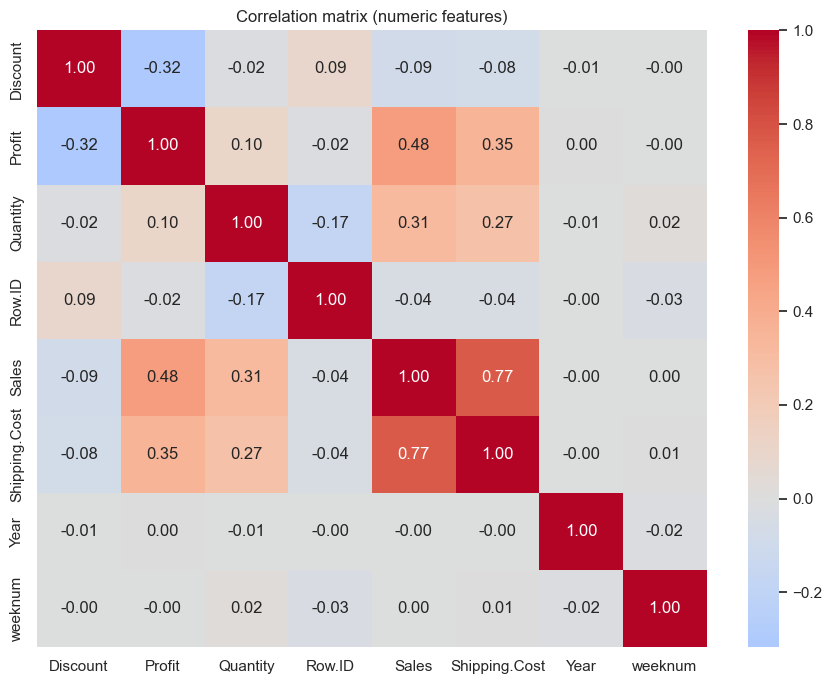

In [18]:
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()


### Q4 i — Strongest positive correlation

**Answer:** The strongest linear association among these numerics is **`Sales` vs `Shipping.Cost`** (correlation ≈ **0.77**): heavier orders tend to incur higher shipping charges.


### Q4 ii — Negatively correlated features

**Answer:** **`Discount` vs `Profit`** (≈ **−0.32**) and **`Discount` vs `Sales`** (weak negative) show the clearest negative relationships—deeper discounts are associated with lower profit and slightly lower sales in this dataset.


### Q4 iii — Most useful bivariate checks for *profit*

We examine **Sales vs Profit**, **Discount vs Profit**, and **Shipping.Cost vs Profit** (core drivers / leakages).


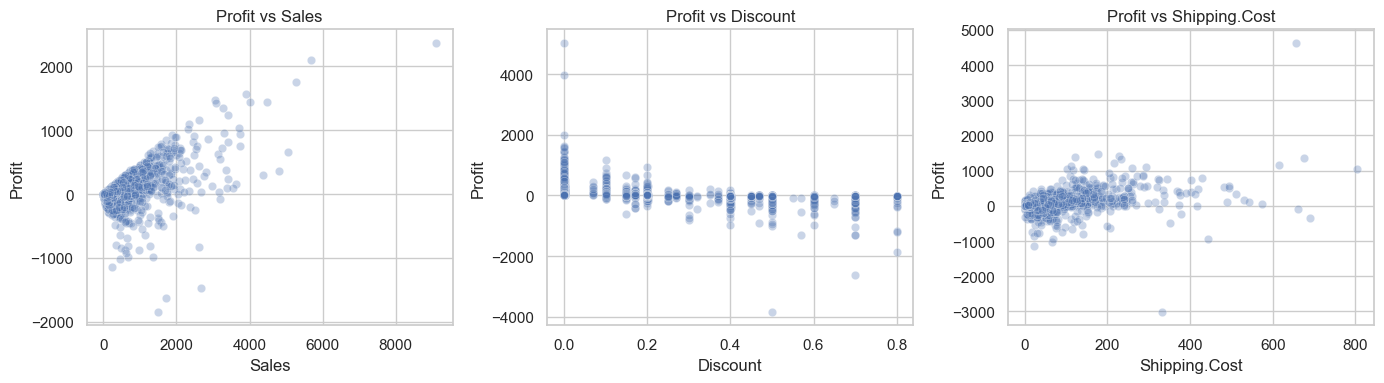

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.scatterplot(data=df.sample(min(5000, len(df))), x="Sales", y="Profit", alpha=0.3, ax=axes[0])
axes[0].set_title("Profit vs Sales")
sns.scatterplot(data=df.sample(min(5000, len(df))), x="Discount", y="Profit", alpha=0.3, ax=axes[1])
axes[1].set_title("Profit vs Discount")
sns.scatterplot(data=df.sample(min(5000, len(df))), x="Shipping.Cost", y="Profit", alpha=0.3, ax=axes[2])
axes[2].set_title("Profit vs Shipping.Cost")
plt.tight_layout()
plt.show()


In [20]:
# Pearson with Profit
profit_corr = corr["Profit"].drop("Profit").sort_values(key=abs, ascending=False)
profit_corr


Sales            0.484923
Shipping.Cost    0.354441
Discount        -0.316490
Quantity         0.104365
Row.ID          -0.019037
Year             0.002626
weeknum         -0.000182
Name: Profit, dtype: float64

**Insights:** Profit rises with Sales overall but with wide dispersion (margin varies). Higher Discount associates with lower Profit. Shipping cost moves with order scale; relationship with profit is positive but confounded by basket size.

### Q4 iv — Time effects

**Note:** `Order.Date` / `Ship.Date` are corrupted in this CSV; we use **`Year`** and **`weeknum`** instead.


In [21]:
yprofit = df.groupby("Year")["Profit"].agg(["mean", "median", "sum"])
yprofit


,mean,median,sum
Year,,,
2011,27.666238,9.0300,248940.81154
2012,28.043722,9.5116,307415.27910
2013,29.490197,9.2400,406935.23018
2014,28.758540,9.2000,504165.97046


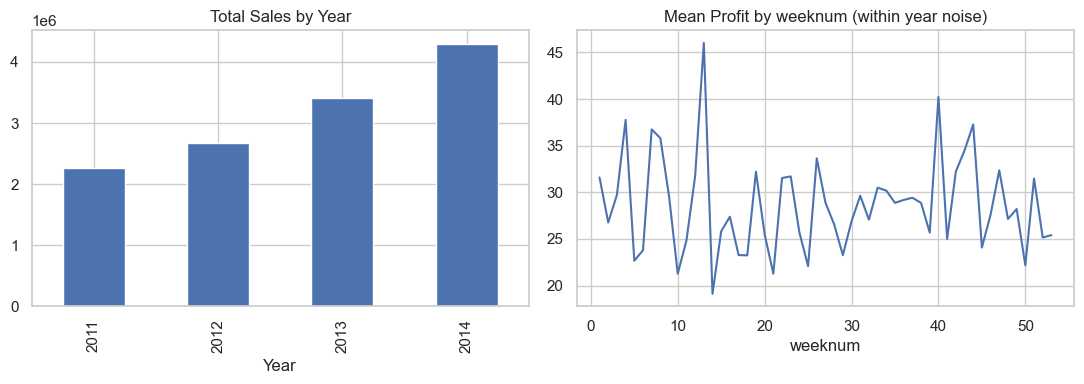

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df.groupby("Year")["Sales"].sum().plot(kind="bar", ax=axes[0], title="Total Sales by Year")
df.groupby("weeknum")["Profit"].mean().plot(ax=axes[1], title="Mean Profit by weeknum (within year noise)")
plt.tight_layout()
plt.show()


**Answer:** **Year** shows mild movement in aggregated profit/sales across 2011–2014 (calendar effects, growth, or sample mix). **weeknum** shows weak mean-profit fluctuation—seasonality is limited at this granularity; finer dates would be needed if the date columns were valid.


## Q5: Bivariate — categorical vs numerical


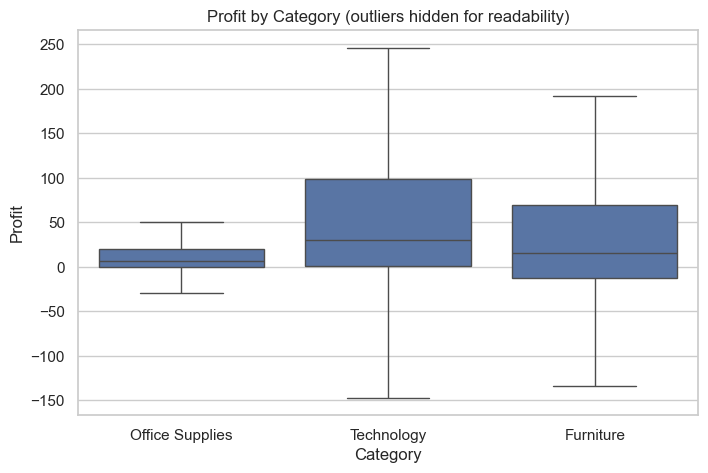

Median profit by Category:
 Category
Office Supplies     6.5538
Furniture          15.5022
Technology         29.9400
Name: Profit, dtype: float64

IQR (Profit) by Category:
 Category
Technology         98.350
Furniture          81.535
Office Supplies    20.130
Name: Profit, dtype: float64


In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="Category", y="Profit", showfliers=False)
plt.title("Profit by Category (outliers hidden for readability)")
plt.show()

cat_med = df.groupby("Category")["Profit"].median().sort_values()
cat_iqr = df.groupby("Category")["Profit"].apply(lambda s: s.quantile(0.75) - s.quantile(0.25))
print("Median profit by Category:\n", cat_med)
print("\nIQR (Profit) by Category:\n", cat_iqr.sort_values(ascending=False))


### Q5 i — Profit by Category

**Answer:** **Highest median profit:** **Technology**. **Lowest median profit:** **Office Supplies**. **Widest spread (largest IQR):** **Technology** (then Furniture). That suggests Technology profit per line is both higher at the median and **less consistent** (more variability) than Office Supplies.


In [24]:
cat_sales_med = df.groupby("Category")["Sales"].median().sort_values(ascending=False)
print("Median Sales by Category:\n", cat_sales_med)


Median Sales by Category:
 Category
Technology         260.0
Furniture          220.0
Office Supplies     46.0
Name: Sales, dtype: float64


### Q5 ii — Sales by Category

**Answer:** **Technology** has the **highest median sales** per row. It also has the **highest median profit**, so high sales and high median profit align for Technology here.


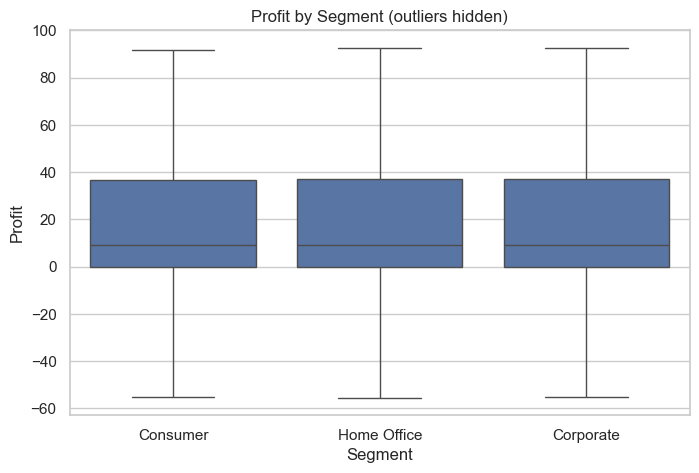

Median profit by Segment:
 Segment
Home Office    9.3200
Corporate      9.3152
Consumer       9.1800
Name: Profit, dtype: float64

Count of negative-profit rows by Segment:
 Segment
Consumer       6521
Corporate      3771
Home Office    2252
dtype: int64


In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="Segment", y="Profit", showfliers=False)
plt.title("Profit by Segment (outliers hidden)")
plt.show()

seg_med = df.groupby("Segment")["Profit"].median().sort_values(ascending=False)
neg_counts = df[df["Profit"] < 0].groupby("Segment").size()
print("Median profit by Segment:\n", seg_med)
print("\nCount of negative-profit rows by Segment:\n", neg_counts.sort_values(ascending=False))


### Q5 iii — Profit by Segment

**Answer:** **Highest median profit:** **Home Office** (slightly above Corporate/Consumer). For **negative-profit “tail” behavior**, **Consumer** has the **largest count of loss-making line items**, i.e., more frequent deep losses than other segments (still inspect with boxplots including outliers for extremes).


In [26]:
df.groupby("Segment")["Sales"].median()


Segment
Consumer       85.0
Corporate      85.0
Home Office    85.0
Name: Sales, dtype: float64

### Q5 iv — Sales by Segment

**Answer:** **Median sales per line** are effectively tied across segments (same median in this data). **Profit pattern is not identical**—slight median differences by segment—so profit drivers are not fully explained by line-level sales alone (mix, discount, category differ).


## Q6: Market vs Region, Category, Country


Chi-square Market x Region: 239549.6627912175 p-value: 0.0


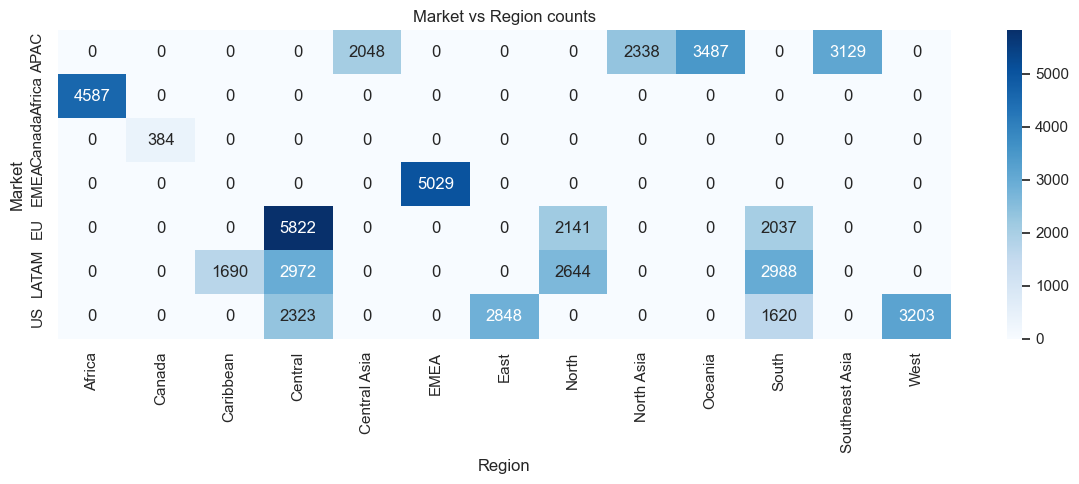

In [27]:
ct_mr = pd.crosstab(df["Market"], df["Region"])
chi2, p, dof, exp = chi2_contingency(ct_mr)
print("Chi-square Market x Region:", chi2, "p-value:", p)
plt.figure(figsize=(12, 5))
sns.heatmap(ct_mr, annot=True, fmt="d", cmap="Blues")
plt.title("Market vs Region counts")
plt.tight_layout()
plt.show()


### Q6 i — Is Market randomly spread across Regions?

**Answer:** **No.** Chi-square is enormous with **p ≈ 0**; each `Market` maps almost exclusively to specific `Region` values (e.g., US→East/Central/South/West, APAC split across Asia regions). This is a **structural** relationship, not a uniform random draw.


In [28]:
# Office Supplies share by Country (negligible = very small counts)
os = df[df["Category"] == "Office Supplies"]
os_counts = os.groupby("Country").size().sort_values()
print("Lowest Office Supplies order counts:")
print(os_counts.head(15))


Lowest Office Supplies order counts:
Country
Armenia                  1
Bahrain                  1
Eritrea                  1
Swaziland                1
Equatorial Guinea        2
Guadeloupe               2
Lesotho                  2
Chad                     2
Tajikistan               2
Slovenia                 2
Macedonia                3
Republic of the Congo    3
Montenegro               3
Lebanon                  4
Paraguay                 4
dtype: int64


### Q6 ii — Country with negligible Office Supplies orders

**Answer:** Several countries have only **1** Office Supplies line in this extract (e.g., **Armenia, Bahrain, Eritrea, Swaziland**—tie at the minimum). Treat as **negligible / thin** for any Office Supplies insight.


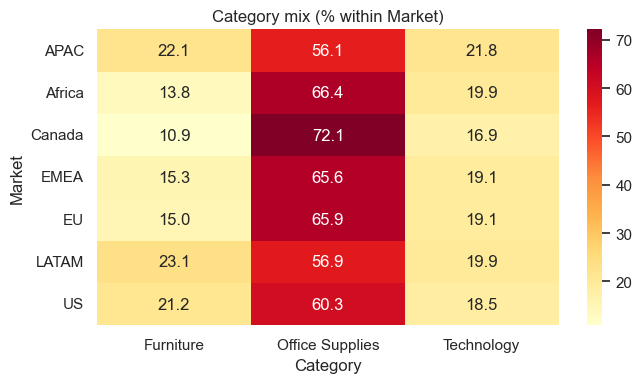

Number of countries touched per Market:
Market
Africa    45
EMEA      40
LATAM     24
APAC      23
EU        15
Canada     1
US         1
dtype: int64


In [29]:
ct_mk = pd.crosstab(df["Market"], df["Category"], normalize="index") * 100
plt.figure(figsize=(7, 4))
sns.heatmap(ct_mk, annot=True, fmt=".1f", cmap="YlOrRd")
plt.title("Category mix (% within Market)")
plt.tight_layout()
plt.show()

ct_mct = pd.crosstab(df["Market"], df["Country"])
# Countries per market
print("Number of countries touched per Market:")
print((ct_mct > 0).sum(axis=1).sort_values(ascending=False))


### Q6 iii — Most useful insights

**Answer:** (1) **Market and Region are essentially hierarchical**—use one of them to avoid redundant features. (2) **Category mix differs by Market** (see heatmap)—growth strategy should be market-specific. (3) **Many countries have tiny counts**—aggregate or group “Rest of world” for stable metrics. (4) **US concentration** from Q3 remains: global KPIs need country filters.

---
_End of required questions._
